In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os

# import beamforming.beamforming_module as bm
import beamforming.read_sims_module as rm
import beamforming.signal_module as sm
import beamforming.sampling_module_para as sp
import beamforming.parameter_reconstruction as rec

from beamforming.sampler_init import (cubic_bound_function, 
                                      cubic_init, 
                                      sphere_bound_function, 
                                      sphere_init, 
                                      xyz_parameter_bounds, 
                                      flat_sphere_bound_function, 
                                      flat_sphere_init,
                                      create_regular_grid)
# from beamforming.beamformed_recs_para_tempering import run_parallel_tempering
from time import time
R2D = 180./np.pi
B_vec = np.array([-20.16850382,  10.52718602, 0.37808577])  # Tesla
B_vec = B_vec / np.linalg.norm(B_vec)

SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)

# SphericalPhasing: Reconstruction visualization

This notebook loads a Tau event and the corresponding beamformed reconstruction samples, then provides multiple visualizations to explore the reconstructed walker positions and beamformed intensities.

Purpose and structure:
- Load event traces and antenna signals from a Tau library.
- Load reconstruction samples produced by the sampling scripts (MCMC / grid).
- Visualize walker positions and beamformed intensities using scatter plots, 2D histograms, and corner plots.

Prerequisites:
- Run the reconstruction scripts (for example `compute_recons.py`) so `results/.../event{event_i}.npz` files exist.
- Make sure `PATH_TO_LIBRARY` points to a valid Tau library `.npz` file.

Use this notebook to inspect individual events and verify spatial and directional structure of the reconstructions.

## Configuration

The following cell sets file paths and parameters used throughout the notebook. Key variables:

- `PATH_TO_LIBRARY`: path to the Tau library (.npz) containing simulated events.
- `SAVE_PATH`: output directory for plots/results.
- `SAMPLING`, `N_WALKERS`, `N_STEPS`, `CELL_SIZE`, `INTENS_METHOD`, `TEMP`, `STEP_SIZE`: sampling/reconstruction settings.
- `BOUNDS`, `R`, `THICKNESS`: geometry and sampler bounds.
- `F_MIN`, `F_MAX`, `NOISE_STD`, `JITTER_STD`: signal-processing parameters applied when reading traces.

In [ ]:
PATH_TO_LIBRARY = "/volatile/home/af274537/Documents/WorkingDir/HERON/SphericalPhasing_2/data/TauLibrary_972Events_Eshower_2e7-1e9GeV_XYZCoordinates_CorrXmax.npz"
SAVE_PATH = './results'

SAMPLING = "random"                         # Can be "cubic_grid", "parallel_tempering", "metrop_hasting"
N_WALKERS = 200                                          # Set to an integer for "parallel_tempering" or "metrop_hasting" else None
N_STEPS = 4000                                           # Number of sampling steps should be > 1 if SAMPLING != "cubic_grid" else None
CELL_SIZE = None                                        # Set to an integer for "cubic_grid" else None
INTENS_METHOD = "amplitude"                                 # can be "amplitude" or "power"
TEMP = 5000.                                            # Only for "metrop_hasting"
F_MIN, F_MAX, NOISE_STD, JITTER_STD = 0, 5000, 0, 0     # Signal processing parameters
STEP_SIZE = 1000.                                        # Step size for "parallel_tempering" and "metrop_hasting"

BOUNDS = "flat_sphere"                                  # can be "cubic", "sphere", "flat_sphere"
R = 10.e3                                               # Only for "sphere" and "flat_sphere"  
THICKNESS = 1000.                                        # Only for "flat_sphere"
XMAX_METHOD = 'max'                                     # can be 'max' or 'avg' or 'mode'
N_BEST_WALKERS = 0                                     # Number of best walkers to consider for Xmax and direction estimation
SEP_WALKERS = False                                     # Whether to separate walkers for direction estimation
BURN_IN = 0      
tau_events, antennas, efields, sttimes = rm.read_library(PATH_TO_LIBRARY)

: 

Tips:
- Change `event_i` (below) to view a different event.
- If you don't have reconstructions available, run `compute_recons.py` or check `results/` for `.npz` files.

In [33]:
event_i = 9

## Select event and read traces

Set `event_i` to the index you want to inspect. The next cell calls `rm.read_trace(...)` which returns:

(_azim, _zen, _en_nu, _en_tau, _tau_pos, _xmax_pos, _event_efield, _antenna_pos, _xant, _yant, _zant, _signals, _phi, _theta, _shower_dir)

- `_signals` contains the antenna time-series used for beamforming.
- `_xmax_pos` is the shower maximum position (used as a reference origin for walker positions).
- `_shower_dir` is the reconstructed/true shower direction vector.

Change `event_i` to inspect other events. If plots look empty, verify the matching `results/.../event{event_i}.npz` file exists.

In [34]:
(_azim, _zen, _en_nu, 
_en_tau, _tau_pos, _xmax_pos, 
_event_efield, _antenna_pos, 
_xant, _yant, _zant, 
_signals, _phi, _theta, _shower_dir) =  rm.read_trace(event_i, tau_events, antennas, efields, sttimes, F_MIN, F_MAX, NOISE_STD, JITTER_STD)

In [35]:
amps = np.max( np.linalg.norm(_signals[1:], axis=0), axis=-1 )
layout_dir = np.average(_antenna_pos, axis=0, weights=amps) - _xmax_pos
layout_dir = layout_dir / np.linalg.norm(layout_dir)


In [36]:
recons_dir = f"./results/samples_sampling{SAMPLING}_nwalkers{N_WALKERS}_nsteps{N_STEPS}_stepsize{STEP_SIZE:.0f}_bounds{BOUNDS}_intens{INTENS_METHOD}_temp{TEMP:.0f}"
recons_dir = f"./results/AAAAAAAAAAAAAAAAAAAAAAAAAAAA_samples_samplingrandom_nwalkers200_nsteps400_stepsize1000_boundsflat_sphere_intensamplitude_temp5000"
recons_samples_npz = np.load( f"{recons_dir}/event{event_i}.npz" )
walker_positions = recons_samples_npz['walker_positions']
walker_intensities = recons_samples_npz['beamformed_intensity_array']

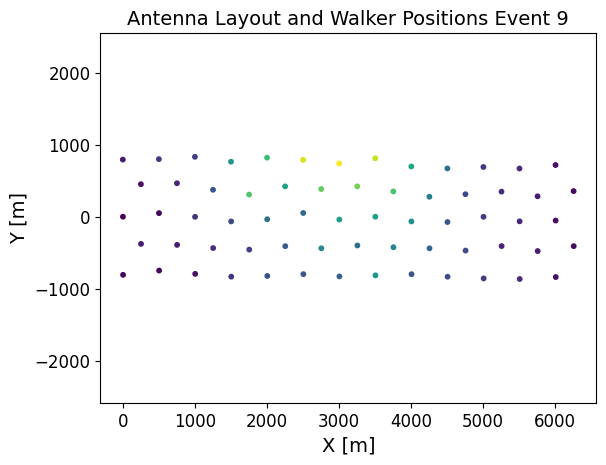

Text(0, 0.5, 'Z [m]')

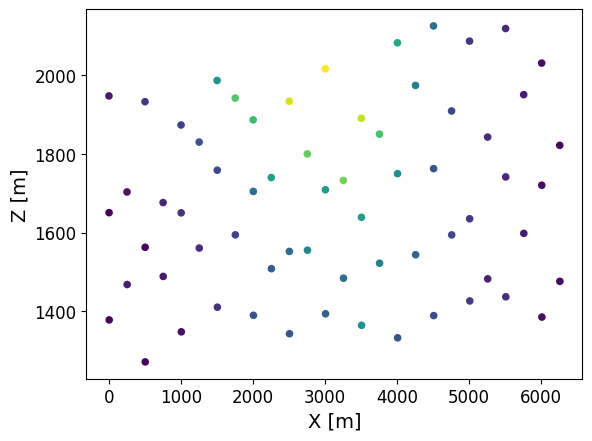

In [47]:
plt.scatter(_antenna_pos[:,0], _antenna_pos[:,1], c=amps, s=10)
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title(f"Antenna Layout and Walker Positions Event {event_i}")
plt.gca().set_aspect('equal', adjustable='datalim')
plt.show()
plt.scatter(_antenna_pos[:,0], _antenna_pos[:,2], c=amps, s=20)
plt.xlabel("X [m]")
plt.ylabel("Z [m]")
# plt.scatter(walker_positions[...,0], walker_positions[...,1], c=walker_intensities, s=5, alpha=0.5, cmap='jet')

In [38]:
bad = np.isnan(walker_positions[:, :, 0].flatten())

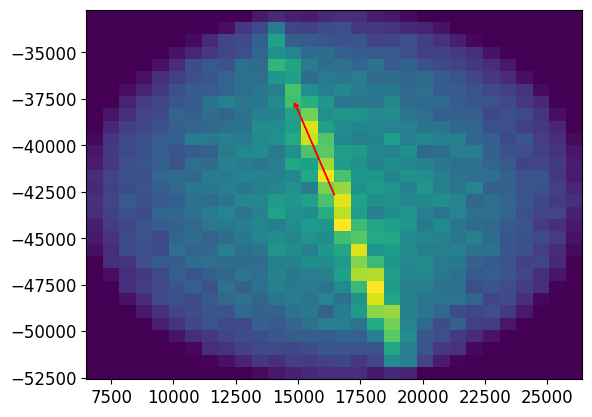

In [39]:
plt.hist2d(walker_positions[:, :, 0].flatten()[~bad], walker_positions[:, :, 1].flatten()[~bad], bins=30, weights=walker_intensities.flatten()[~bad])
plt.arrow(_xmax_pos[0], _xmax_pos[1], 5000.*_shower_dir[0], 5000.*_shower_dir[1], color='red', head_width=200., head_length=200.)

(array([1.61794028e+24, 3.40348491e+24, 4.66836641e+24, 6.15349134e+24,
        7.98861819e+24, 1.16534837e+25, 2.86673353e+25, 3.60091788e+25,
        8.06730436e+25, 1.23724609e+26, 2.94735208e+28, 1.09884940e+30,
        1.47210697e+30, 1.66054475e+31, 1.05895050e+32, 6.95201549e+31,
        3.47734544e+31, 2.80396986e+31, 1.62273102e+31, 3.45397446e+30,
        3.43327553e+26, 2.14715885e+26, 2.10320829e+26, 9.60469362e+25,
        2.47247068e+25, 9.97494586e+24, 4.72664233e+24, 2.78878515e+24,
        1.56808902e+24, 3.17183294e+23]),
 array([ 6499.21304715,  7162.69321975,  7826.17339235,  8489.65356495,
         9153.13373755,  9816.61391015, 10480.09408276, 11143.57425536,
        11807.05442796, 12470.53460056, 13134.01477316, 13797.49494576,
        14460.97511836, 15124.45529096, 15787.93546356, 16451.41563616,
        17114.89580876, 17778.37598136, 18441.85615396, 19105.33632656,
        19768.81649916, 20432.29667176, 21095.77684436, 21759.25701697,
        22422.73718957

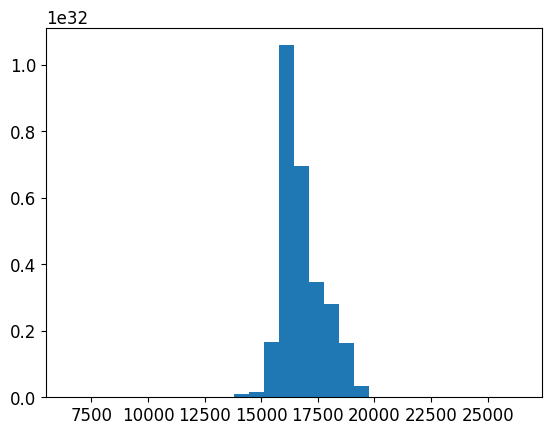

In [40]:
plt.hist(walker_positions[:, :, 0].flatten(), bins=30, weights=walker_intensities.flatten()**10)

### Quick histogram and 2D density checks

The cells above provide quick visual checks:
- Scatter of antenna layout colored by peak amplitude helps check the signal footprint.
- Walker scatter (colored by beamformed intensity) shows where the sampler thinks the source might be.
- The 2D histogram (weighted by intensity) highlights dense/high-intensity regions.

Run these quick checks first to ensure the reconstruction has sensible spatial structure before running more detailed corner plots and projections below.

In [41]:
from matplotlib.colors import LogNorm

def corner_plot(data, weights=None, labels=None, bins=40, figsize=4, 
                hist2d_cmap="Blues", contour_levels=None, equal=True):
    """
    data : array-like, shape (n_samples, n_dim)
    weights : optional weights, shape (n_samples,)
    labels : list of axis labels
    bins : number of bins
    contour_levels : None or list of contour levels (fractions of max density)
    """
    data = np.asarray(data)
    n, d = data.shape
    
    if labels is None:
        labels = [f"x{i}" for i in range(d)]
    
    if contour_levels is None:
        contour_levels = [0.1, 0.5, 0.9]  # 10%, 50%, 90% iso-contours

    fig, axes = plt.subplots(d, d, figsize=(figsize*d, figsize*d))
    
    for i in range(d):
        for j in range(d):
            ax = axes[i, j]
            if i < j:
                ax.axis('off')
                continue

            # Diagonal: weighted 1D histogram
            if i == j:
                ax.hist(data[:, i], bins=bins, weights=weights,
                        color="black", histtype="stepfilled", alpha=0.5)
                ax.hist(data[:, i], bins=bins, weights=weights,
                        color="black", histtype="step", linewidth=1.2)
            # Off-diagonal: weighted 2D histogram + contours
            else:
                # column j should be the x-axis and column i the y-axis for axes[i,j]
                x = data[:, j]
                y = data[:, i]

                H, xedges, yedges = np.histogram2d(
                    x, y, bins=bins, weights=weights
                )

                # pcolormesh expects the grid defined by edges; H needs to be transposed
                ax.pcolormesh(xedges, yedges, H.T, cmap=hist2d_cmap, norm=LogNorm())

                # contour using bin centers (transpose H to match Xc/Yc shapes)
                x_centers = 0.5*(xedges[:-1] + xedges[1:])
                y_centers = 0.5*(yedges[:-1] + yedges[1:])
                Xc, Yc = np.meshgrid(x_centers, y_centers)
                levels = [lvl * H.max() for lvl in contour_levels]
                ax.contour(Xc, Yc, H.T, levels=levels, colors="black")
                if equal:
                    ax.set_aspect('equal', adjustable='datalim')
            # Aesthetic cleanup & correct labeling:
            # only bottom row shows x tick labels (variable j), only left column shows y labels (variable i)
            if i < d - 1:
                ax.set_xticks([])
            else:
                ax.set_xlabel(labels[j])
            if j > 0:
                ax.set_yticks([])
            else:
                if i != 0:
                    ax.set_ylabel(labels[i])

    plt.tight_layout()
    return fig, axes


### Corner plot helper

`corner_plot(data, weights=None, labels=None, bins=40, figsize=4, hist2d_cmap="Blues", contour_levels=None, equal=True)` creates a matrix of subplots where:

- Diagonal: weighted 1D histograms for each variable.
- Off-diagonal: weighted 2D density (pcolormesh) with optional contour levels.

Usage notes for this notebook:
- `data` should be shape `(n_samples, n_dim)` with samples in rows.
- `weights` can emphasize high-intensity samples. In this notebook we sometimes raise intensities to a power (e.g. **8 or **20) before normalizing to highlight strong peaks.
- `labels` is a list of axis names (shown on bottom/left plots).
- Use `equal=False` for coordinate pairs where aspect ratio shouldn't be forced (e.g., R vs angle).

Call examples later in this notebook show `corner_plot(...)` applied to walker coordinates and to coordinates projected along physically meaningful axes.

# Different representations


Representation in classical X,Y,Z coordinate system

[-9960.11780023 -9918.8668634  -3993.66146008] [9944.28737779 9968.7825322  3994.83094875]


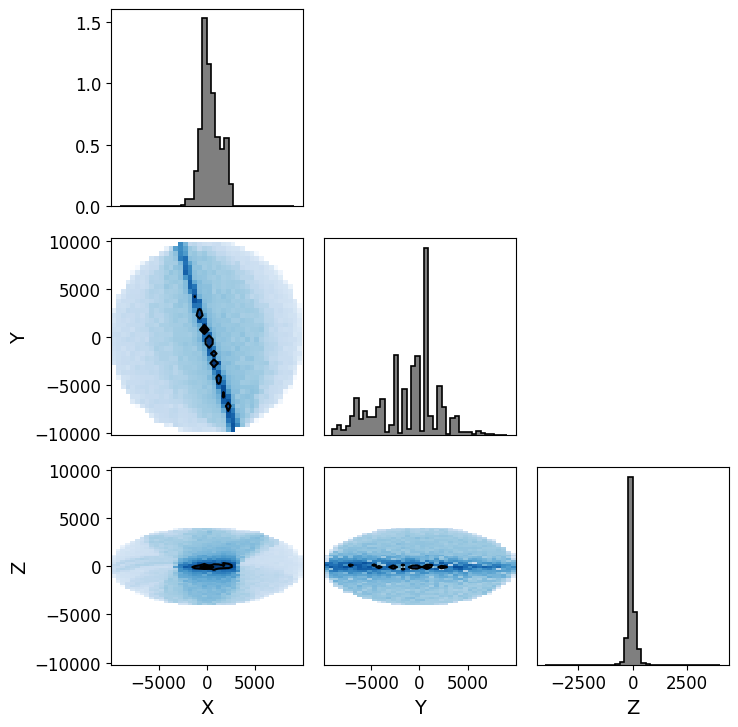

In [42]:
np.random.seed(0)
N = 5000

data = np.column_stack([
    walker_positions[:, :, 0].flatten()[~bad],
    walker_positions[:, :, 1].flatten()[~bad],
    walker_positions[:, :, 2].flatten()[~bad]
])
data = data - _xmax_pos
print(data.min(axis=0), data.max(axis=0))

weights = walker_intensities.flatten()[~bad]**8
weights = weights/weights.max()
fig, axes = corner_plot(data, weights=weights, labels=["X", "Y", "Z"], figsize=2.5)
plt.show()


Representation in **k**, **k**x**B**, **k**x**k**x**B** coordinate system. 0,0,0 is the true location of Xmax, the shower axis is along (0, **k**)

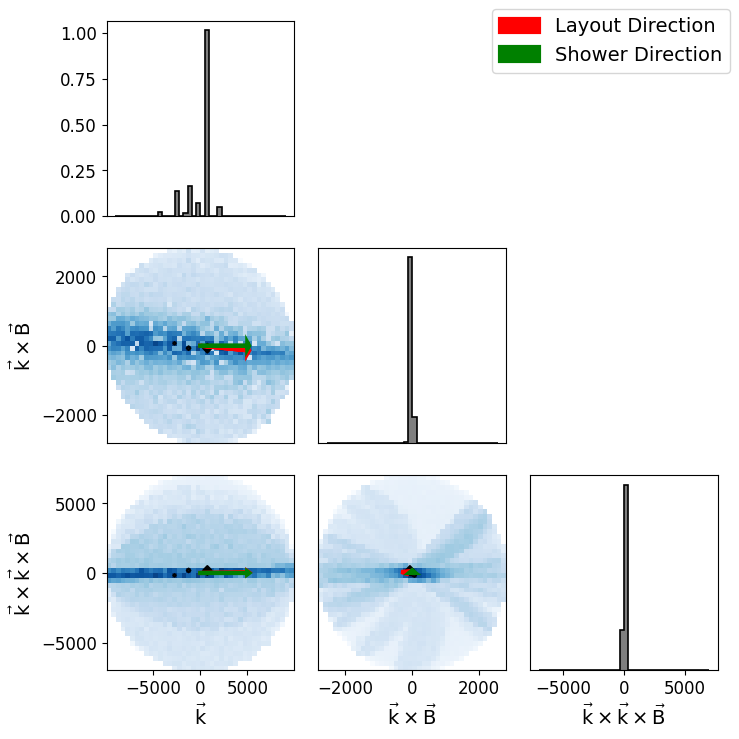

In [43]:
k = _shower_dir
kxB = np.cross(k, B_vec)
kxkxB = np.cross(k, kxB)

k_arrow = np.array([1, 0, 0])
layout_arrow = np.array([
    (layout_dir * k).sum(),
    (layout_dir * kxB).sum(),
    (layout_dir * kxkxB).sum(),
    ])
walkers_on_k = ((walker_positions - _xmax_pos) * k).sum(axis=2)
walkers_on_kxB = ((walker_positions - _xmax_pos) * kxB).sum(axis=2)
walkers_on_kxkxB = ((walker_positions - _xmax_pos) * kxkxB).sum(axis=2)

data = np.column_stack([
    walkers_on_k.flatten()[~bad],
    walkers_on_kxB.flatten()[~bad],
    walkers_on_kxkxB.flatten()[~bad]
])

weights = walker_intensities.flatten()[~bad]**20
weights = weights/weights.max()
ax_labels = ["$\\vec{ \\rm k}$", "$\\vec{ \\rm k} \\times \\vec{ \\rm B}$", "$\\vec{ \\rm k} \\times \\vec{ \\rm k} \\times \\vec{ \\rm B}$"]
fig, axes = corner_plot(data, weights=weights, 
                        labels=ax_labels, figsize=2.5, equal=False)
axes[1,0].arrow(0, 0, 5000.*layout_arrow[0], 5000.*layout_arrow[1], color='red', head_width=200., head_length=200., lw=3, zorder=2000, label='Layout Direction')
axes[1,0].arrow(0, 0, 5000.*k_arrow[0], 5000.*k_arrow[1], color='green', head_width=200., head_length=200., lw=3, zorder=2000, label='Shower Direction')

axes[2,0].arrow(0, 0, 5000.*layout_arrow[0], 5000.*layout_arrow[2], color='red', head_width=200., head_length=200., lw=3, zorder=2000, label='Layout Direction')
axes[2,0].arrow(0, 0, 5000.*k_arrow[0], 5000.*k_arrow[2], color='green', head_width=200., head_length=200., lw=3, zorder=2000, label='Shower Direction')

axes[2,1].arrow(0, 0, 5000.*layout_arrow[1], 5000.*layout_arrow[2], color='red', head_width=200., head_length=200., lw=3, zorder=2000, label='Layout Direction')
axes[2,1].arrow(0, 0, 5000.*k_arrow[1], 5000.*k_arrow[2], color='green', head_width=200., head_length=200., lw=3, zorder=2000, label='Shower Direction')


handle, labels = axes[1,0].get_legend_handles_labels()
fig.legend(handles=handle, labels=labels)
plt.show()

Representation in **k**, **$\bm e_{\rm \theta}$**, **$\bm e_{\rm \phi}$** coordinate system. 0,0,0 is the true location of Xmax, the shower axis is along (0, **k**). 

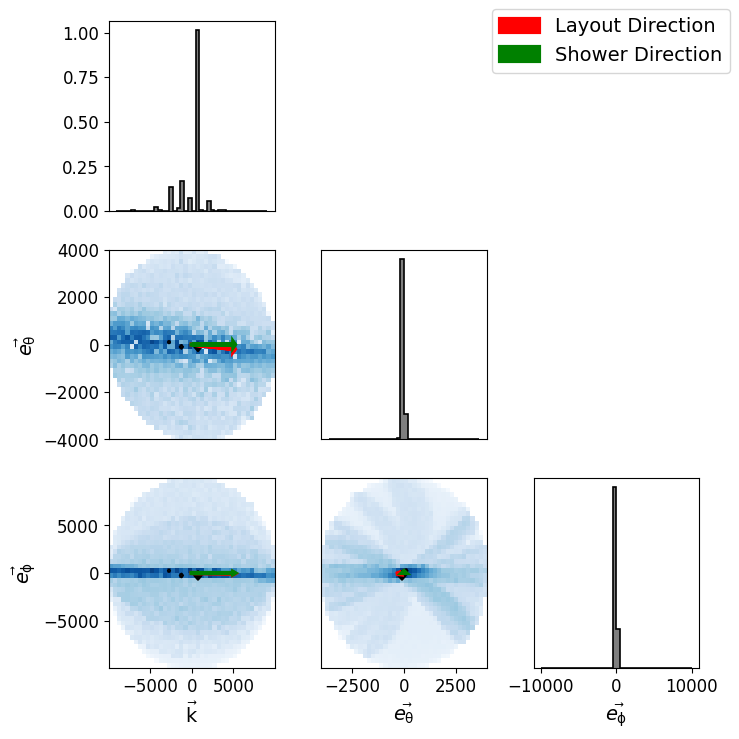

In [44]:
k = _shower_dir
e_theta = np.array([-np.cos(_theta)*np.cos(_phi), -np.cos(_theta)*np.sin(_phi), np.sin(_theta)])
e_phi = np.array([np.sin(_phi), -np.cos(_phi), 0])

k_arrow = np.array([1, 0, 0])
layout_arrow = np.array([
    (layout_dir * k).sum(),
    (layout_dir * e_theta).sum(),
    (layout_dir * e_phi).sum(),
    ])
walkers_on_k = ((walker_positions - _xmax_pos) * k).sum(axis=2)
walkers_on_theta = ((walker_positions - _xmax_pos) * e_theta).sum(axis=2)
walkers_on_phi = ((walker_positions - _xmax_pos) * e_phi).sum(axis=2)

data = np.column_stack([
    walkers_on_k.flatten()[~bad],
    walkers_on_theta.flatten()[~bad],
    walkers_on_phi.flatten()[~bad]
])

weights = walker_intensities.flatten()[~bad]**20
weights = weights/weights.max()
ax_labels = ["$\\vec{ \\rm k}$", "$\\vec{ e_{\\rm \\theta}}$", "$\\vec{ e_{\\rm \\phi}}$"]
fig, axes = corner_plot(data, weights=weights, 
                        labels=ax_labels, figsize=2.5, equal=False)
axes[1,0].arrow(0, 0, 5000.*layout_arrow[0], 5000.*layout_arrow[1], color='red', head_width=200., head_length=200., lw=3, zorder=2000, label='Layout Direction')
axes[1,0].arrow(0, 0, 5000.*k_arrow[0], 5000.*k_arrow[1], color='green', head_width=200., head_length=200., lw=3, zorder=2000, label='Shower Direction')

axes[2,0].arrow(0, 0, 5000.*layout_arrow[0], 5000.*layout_arrow[2], color='red', head_width=200., head_length=200., lw=3, zorder=2000, label='Layout Direction')
axes[2,0].arrow(0, 0, 5000.*k_arrow[0], 5000.*k_arrow[2], color='green', head_width=200., head_length=200., lw=3, zorder=2000, label='Shower Direction')

axes[2,1].arrow(0, 0, 5000.*layout_arrow[1], 5000.*layout_arrow[2], color='red', head_width=200., head_length=200., lw=3, zorder=2000, label='Layout Direction')
axes[2,1].arrow(0, 0, 5000.*k_arrow[1], 5000.*k_arrow[2], color='green', head_width=200., head_length=200., lw=3, zorder=2000, label='Shower Direction')


handle, labels = axes[1,0].get_legend_handles_labels()
fig.legend(handles=handle, labels=labels)
plt.show()

: 

Representation in cylindrical coordinate, 
- The coordinate along the direction of the shower axis **k**  
- R is the distance to the shower axis
- $\eta$ is the angle from the vertical around the shower axis

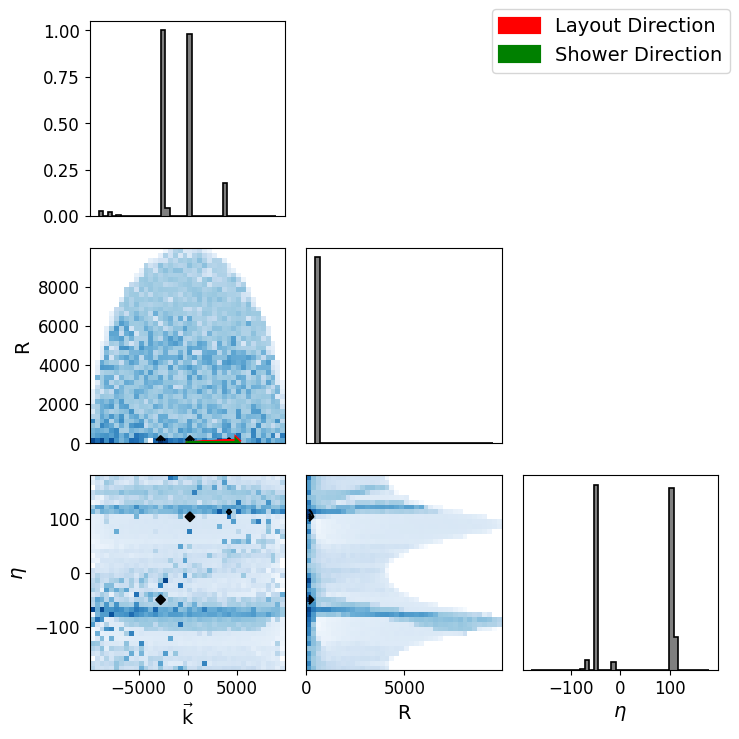

: 

In [ ]:
k = _shower_dir
kxB = np.cross(k, B_vec)
kxkxB = np.cross(k, kxB)

walkers_on_k = ((walker_positions - _xmax_pos) * k).sum(axis=2)
walkers_on_kxB = ((walker_positions - _xmax_pos) * kxB).sum(axis=2)
walkers_on_kxkxB = ((walker_positions - _xmax_pos) * kxkxB).sum(axis=2)

walkers_on_R = np.sqrt( walkers_on_kxB**2 + walkers_on_kxkxB**2 )
walkers_on_eta = np.arctan2( walkers_on_kxkxB, walkers_on_kxB )  

k_arrow_polar = np.array([1, 0, 0])

layout_on_k = (layout_dir * k).sum()
layout_on_kxB = (layout_dir * kxB).sum()
layout_on_kxkxB = (layout_dir * kxkxB).sum()

layout_on_R = np.sqrt( layout_on_kxB**2 + layout_on_kxkxB**2 )
layout_on_eta = np.arctan2( layout_on_kxkxB, layout_on_kxB )

data = np.column_stack([
    walkers_on_k.flatten()[~bad],
    walkers_on_R.flatten()[~bad],
    walkers_on_eta.flatten()[~bad]*R2D
])

weights = walker_intensities.flatten()[~bad]**20
weights = weights/weights.max()
ax_labels = ["$\\vec{ \\rm k}$", "R", "$\\eta$"]
fig, axes = corner_plot(data, weights=weights, 
                        labels=ax_labels, figsize=2.5, equal=False)
axes[1,0].arrow(0, 0, 5000.*layout_on_k, 5000.*layout_on_R, color='red', head_width=200., head_length=200., lw=3, zorder=2000, label='Layout Direction')
axes[1,0].arrow(0, 0, 5000.*k_arrow_polar[0], 5000.*k_arrow_polar[1], color='green', head_width=200., head_length=200., lw=3, zorder=2000, label='Shower Direction')

# axes[2,0].arrow(0, 0, 5000.*layout_on_k, layout_on_eta*R2D, color='red', head_width=1., head_length=1., lw=3, zorder=2000, label='Layout Direction')
# axes[2,0].arrow(0, 0, 5000.*k_arrow_polar[0], k_arrow_polar[2]*R2D, color='green', head_width=1., head_length=1., lw=3, zorder=2000, label='Shower Direction') 

# axes[2,1].arrow(0, 0, 5000.*layout_on_R, layout_on_eta*R2D, color='red', head_width=1., head_length=1., lw=3, zorder=2000, label='Layout Direction')
# axes[2,1].arrow(0, 0, 5000.*k_arrow_polar[1], k_arrow_polar[2]*R2D, color='green', head_width=1., head_length=1., lw=3, zorder=2000, label='Shower Direction')

axes[1,0].set_ylim(bottom= 0)
axes[2,1].set_xlim(left= 0)
handle, labels = axes[1,0].get_legend_handles_labels()
fig.legend(handles=handle, labels=labels)
plt.show()

Representation in spherical coordinates.
- R is the distance to Xmax
- Zenith is the angle from the vertical as seen from Xmax
- Azimuth is the angle from the X axis as seen from Xmax

/tmp/ipykernel_139793/322084746.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(handles=handle, labels=labels)


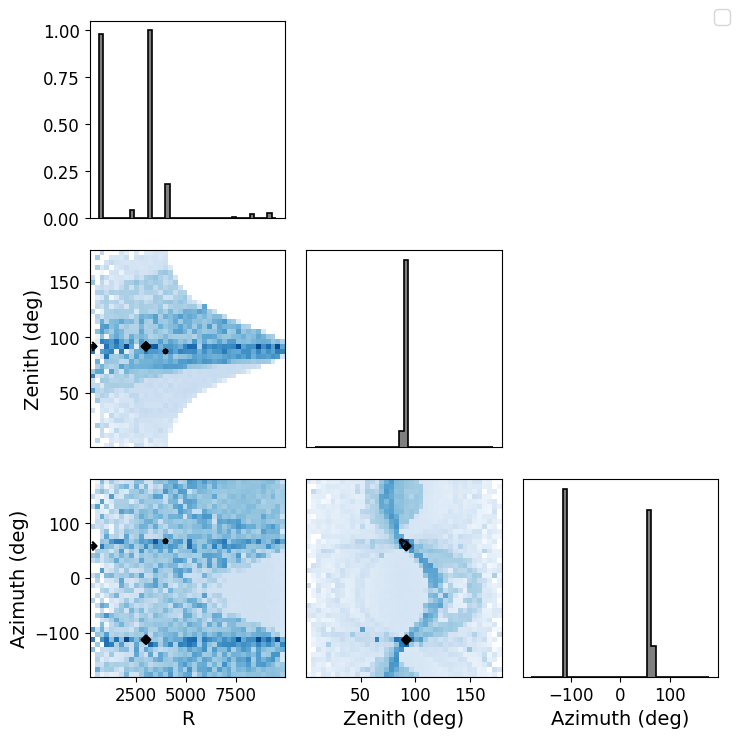

: 

In [ ]:
k = _shower_dir
kxB = np.cross(k, B_vec)
kxkxB = np.cross(k, kxB)

walkers_R = np.linalg.norm(walker_positions - _xmax_pos, axis=2)
walkers_zenith = np.arccos( ((walker_positions - _xmax_pos)[...,2]) / walkers_R )
walkers_azimuth = np.arctan2( (walker_positions - _xmax_pos)[...,1], (walker_positions - _xmax_pos)[...,0] )

data = np.column_stack([
    walkers_R.flatten()[~bad],
    walkers_zenith.flatten()[~bad]*R2D,
    walkers_azimuth.flatten()[~bad]*R2D
])

theta_layout = np.arccos( layout_dir[2] )
phi_layout = np.arctan2( layout_dir[1], layout_dir[0] )
phi_layout_reversed = phi_layout + np.pi if phi_layout < 0 else phi_layout - np.pi

_phi_reversed = _phi +np.pi if _phi < 0 else _phi - np.pi

weights = walker_intensities.flatten()[~bad]**20
weights = weights/weights.max()
ax_labels = ["R", "Zenith (deg)", "Azimuth (deg)"]
fig, axes = corner_plot(data, weights=weights, 
                        labels=ax_labels, figsize=2.5, equal=False)


handle, labels = axes[1,0].get_legend_handles_labels()
fig.legend(handles=handle, labels=labels)
plt.show()

### Relation between the distance to the shower axis, the intensity and the distance along the shower axis

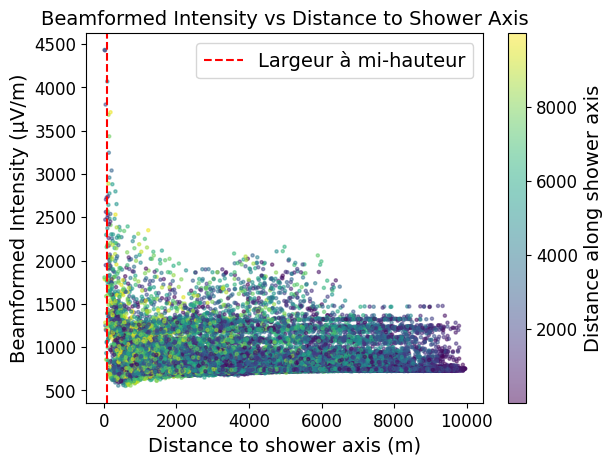

: 

In [ ]:
distance_to_axis = np.sqrt(walkers_on_kxB**2 + walkers_on_kxkxB**2)
scat = plt.scatter(distance_to_axis, walker_intensities.flatten(), alpha=0.5, s=5, c=np.abs(walkers_on_k))
half_max = (walker_intensities.max() + walker_intensities.min())/2.
close_to_half_max = distance_to_axis[np.abs(walker_intensities - half_max) < 5.]
half_max_distance = close_to_half_max.max()
plt.colorbar(scat, label='Distance along shower axis')
plt.axvline(half_max_distance, color='red', linestyle='--', label='Largeur à mi-hauteur')
plt.legend()
# plt.yscale('log')
plt.xlabel("Distance to shower axis (m)")
plt.ylabel("Beamformed Intensity (µV/m)")
plt.title("Beamformed Intensity vs Distance to Shower Axis")
plt.show()

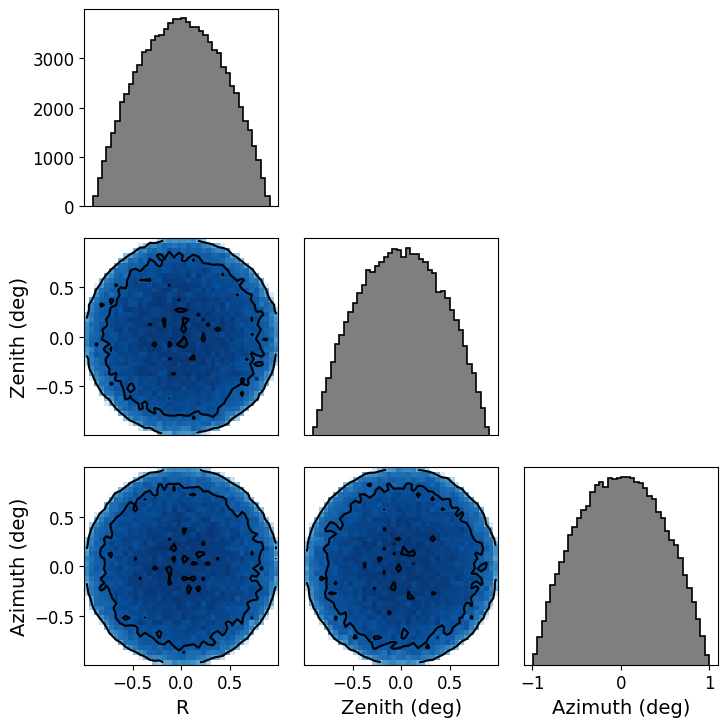

: 

In [ ]:
D = np.random.randn(100000, 3)
D = D / np.linalg.norm(D, axis=1)[:, np.newaxis]
R = np.random.rand(100000, 1)**(1/3) * 1.0
X = D * R
W = np.ones(len(X))
fig, axes = corner_plot(X, weights=W, 
                        labels=ax_labels, figsize=2.5, equal=False)

: 